In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Load the dataset

In [2]:
df = pd.read_csv('Cardiotocographic.csv')

In [3]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [4]:
df.shape

(2126, 14)

In [5]:
df.columns

Index(['LB', 'AC', 'FM', 'UC', 'DL', 'DS', 'DP', 'ASTV', 'MSTV', 'ALTV',
       'MLTV', 'Width', 'Tendency', 'NSP'],
      dtype='object')

### Understanding the Dataset

In [6]:
# Column	Description
# LB	Baseline Fetal Heart Rate
# AC	Accelerations
# FM	Fetal Movements
# UC	Uterine Contractions
# DL	Late Decelerations
# DS	Short Decelerations
# DP	Prolonged Decelerations
# ASTV	Abnormal Short Term Variability
# MSTV	Mean Short Term Variability
# ALTV	Abnormal Long Term Variability
# MLTV	Mean Long Term Variability
# Width	Histogram Width
# Tendency	Histogram Tendency
# NSP	Fetal State Class

### Data Cleaning and Preparation

In [7]:
df.dtypes

LB          float64
AC          float64
FM          float64
UC          float64
DL          float64
DS          float64
DP          float64
ASTV        float64
MSTV        float64
ALTV        float64
MLTV        float64
Width       float64
Tendency    float64
NSP         float64
dtype: object

### checking missing values

In [8]:
df.isnull().sum()

LB          21
AC          20
FM           0
UC           0
DL           0
DS          21
DP          21
ASTV         0
MSTV         0
ALTV         0
MLTV        21
Width       21
Tendency    21
NSP         21
dtype: int64

In [9]:
# percentage of missing values
(df.isnull().sum() / len(df)) * 100

LB          0.987770
AC          0.940734
FM          0.000000
UC          0.000000
DL          0.000000
DS          0.987770
DP          0.987770
ASTV        0.000000
MSTV        0.000000
ALTV        0.000000
MLTV        0.987770
Width       0.987770
Tendency    0.987770
NSP         0.987770
dtype: float64

### Handling Missing Values

In [10]:
# filling numerical missing values with median
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [11]:
df.isnull().sum()

LB          0
AC          0
FM          0
UC          0
DL          0
DS          0
DP          0
ASTV        0
MSTV        0
ALTV        0
MLTV        0
Width       0
Tendency    0
NSP         0
dtype: int64

### Checking Duplicate Rows

In [12]:
df.duplicated().sum()

np.int64(2)

In [13]:
# removing duplicates
df = df.drop_duplicates()

### Checking Inconsistent Data Types

In [14]:
df.head()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
0,120.000000,0.000000,0.0,0.000000,0.000000,0.0,0.0,73.0,0.5,43.0,2.4,64.0,0.999926,2.0
1,132.000000,0.006380,0.0,0.006380,0.003190,0.0,0.0,17.0,2.1,0.0,10.4,130.0,0.000000,1.0
2,133.000000,0.003322,0.0,0.008306,0.003322,0.0,0.0,16.0,2.1,0.0,13.4,130.0,0.000000,1.0
3,134.000000,0.002561,0.0,0.007742,0.002561,0.0,0.0,16.0,2.4,0.0,23.0,117.0,1.000000,1.0
4,131.948232,0.006515,0.0,0.008143,0.000000,0.0,0.0,16.0,2.4,0.0,19.9,117.0,1.000000,1.0


In [15]:
for col in df.columns:
    print(col, ":", df[col].nunique())

LB : 153
AC : 1068
FM : 776
UC : 1364
DL : 822
DS : 114
DP : 264
ASTV : 183
MSTV : 165
ALTV : 195
MLTV : 351
Width : 261
Tendency : 111
NSP : 111


In [16]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2124 entries, 0 to 2125
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   LB        2124 non-null   float64
 1   AC        2124 non-null   float64
 2   FM        2124 non-null   float64
 3   UC        2124 non-null   float64
 4   DL        2124 non-null   float64
 5   DS        2124 non-null   float64
 6   DP        2124 non-null   float64
 7   ASTV      2124 non-null   float64
 8   MSTV      2124 non-null   float64
 9   ALTV      2124 non-null   float64
 10  MLTV      2124 non-null   float64
 11  Width     2124 non-null   float64
 12  Tendency  2124 non-null   float64
 13  NSP       2124 non-null   float64
dtypes: float64(14)
memory usage: 248.9 KB


### Outlier Detection and Treatment

<Axes: >

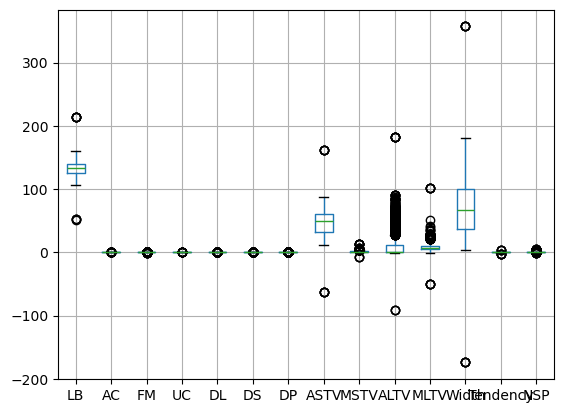

In [17]:
df.boxplot()

In [18]:
# function for outlier capping

def outlier_capping(df,column):
    q1 = df[column].quantile(0.25)
    q3 = df[column].quantile(0.75)
    iqr = q3 - q1

    lower_limit = q1 - 1.5 * iqr
    upper_limit = q3 + 1.5 * iqr

    df[column] = df[column].apply(
        lambda x : lower_limit if x < lower_limit else upper_limit if x > upper_limit else x
    )
for col in df.select_dtypes(include=['int','float']).columns:
    outlier_capping(df,col)

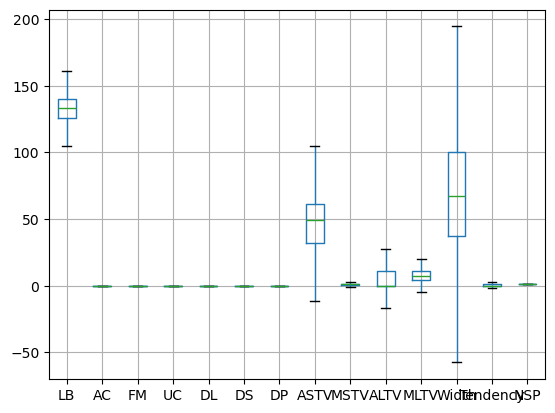

In [19]:
df.boxplot()
plt.show()

### Statistical Summary

In [20]:
df.describe()

,LB,AC,FM,UC,DL,DS,DP,ASTV,MSTV,ALTV,MLTV,Width,Tendency,NSP
count,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0,2124.0,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.000000,2124.0
mean,133.288721,0.003133,0.001570,0.004365,0.001772,0.0,0.0,46.998334,1.304554,6.697979,8.002912,70.318547,0.316835,1.0
std,9.926790,0.003830,0.002487,0.003001,0.002670,0.0,0.0,17.609911,0.781303,10.381254,5.046792,39.577385,0.622623,0.0
min,105.000000,-0.008418,-0.003853,-0.005158,-0.004938,0.0,0.0,-11.500000,-0.800000,-16.500000,-4.700000,-57.500000,-1.500000,1.0
25%,126.000000,0.000000,0.000000,0.001858,0.000000,0.0,0.0,32.000000,0.700000,0.000000,4.600000,37.000000,0.000000,1.0
50%,133.000000,0.001634,0.000000,0.004486,0.000000,0.0,0.0,49.000000,1.200000,0.000000,7.400000,67.000000,0.000000,1.0
75%,140.000000,0.005612,0.002568,0.006536,0.003292,0.0,0.0,61.000000,1.700000,11.000000,10.800000,100.000000,1.000000,1.0
max,161.000000,0.014030,0.006421,0.013552,0.008230,0.0,0.0,104.500000,3.200000,27.500000,20.100000,194.500000,2.500000,1.0


In [21]:
summary = pd.DataFrame()

summary['Mean'] = df.mean(numeric_only=True)
summary['Median'] = df.median(numeric_only=True)
summary['Std'] = df.std(numeric_only=True)
summary['Q1'] = df.quantile(0.25, numeric_only=True)
summary['Q3'] = df.quantile(0.75, numeric_only=True)
summary['IQR'] = summary['Q3'] - summary['Q1']

summary

,Mean,Median,Std,Q1,Q3,IQR
LB,133.288721,133.000000,9.926790,126.000000,140.000000,14.000000
AC,0.003133,0.001634,0.003830,0.000000,0.005612,0.005612
FM,0.001570,0.000000,0.002487,0.000000,0.002568,0.002568
UC,0.004365,0.004486,0.003001,0.001858,0.006536,0.004678
DL,0.001772,0.000000,0.002670,0.000000,0.003292,0.003292
DS,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
DP,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
ASTV,46.998334,49.000000,17.609911,32.000000,61.000000,29.000000
MSTV,1.304554,1.200000,0.781303,0.700000,1.700000,1.000000
ALTV,6.697979,0.000000,10.381254,0.000000,11.000000,11.000000


## Data Visualization

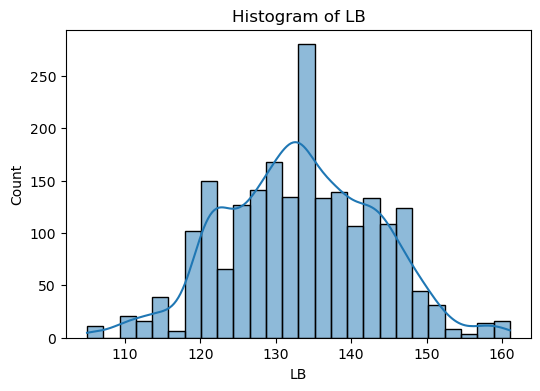

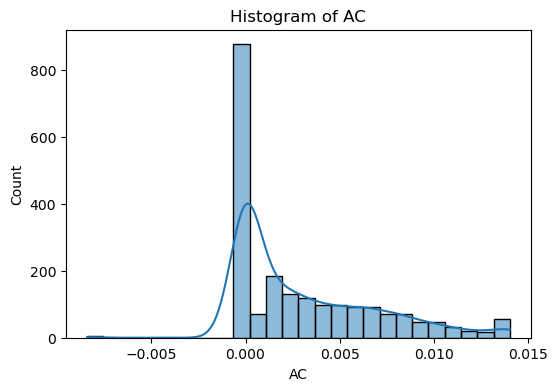

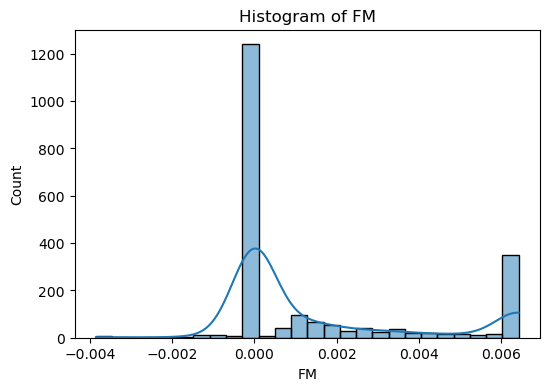

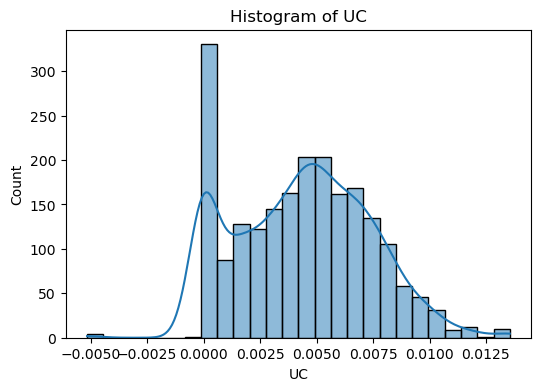

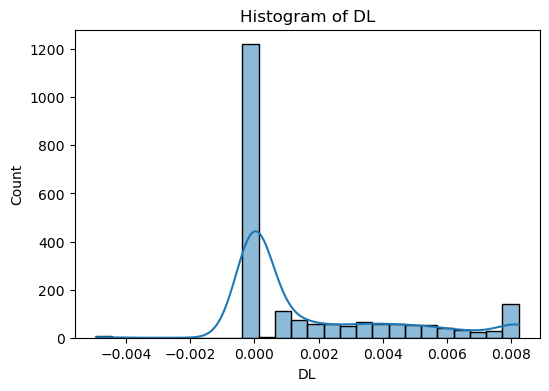

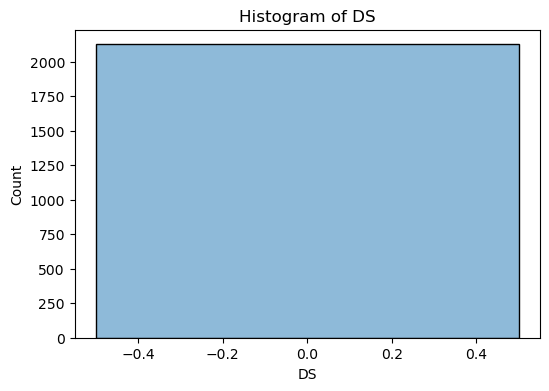

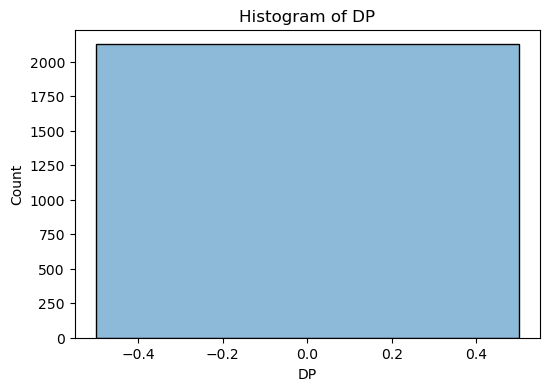

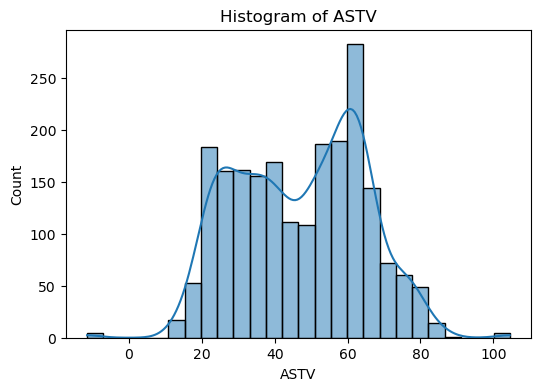

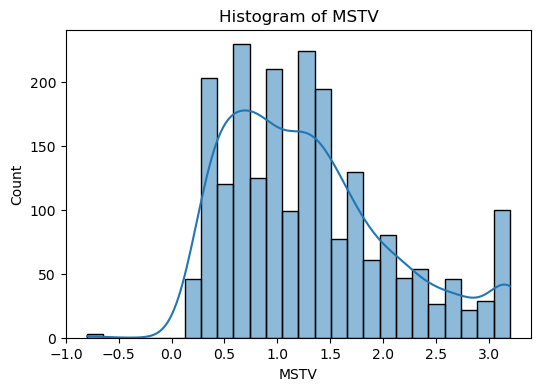

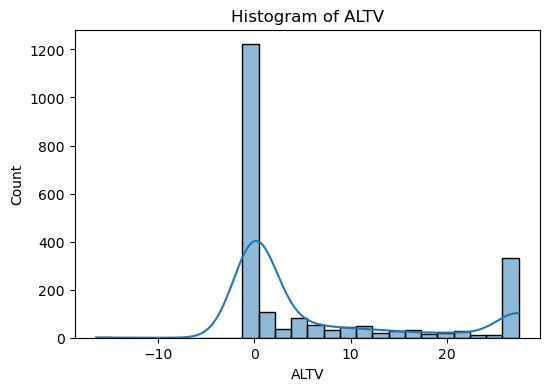

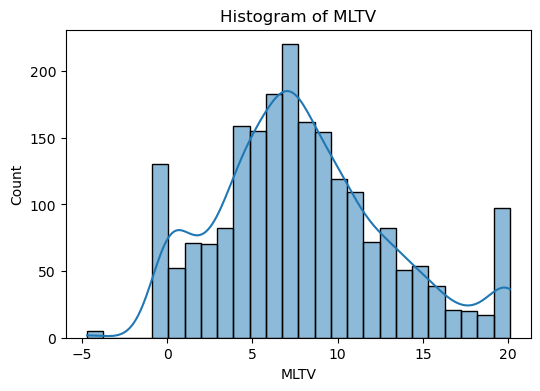

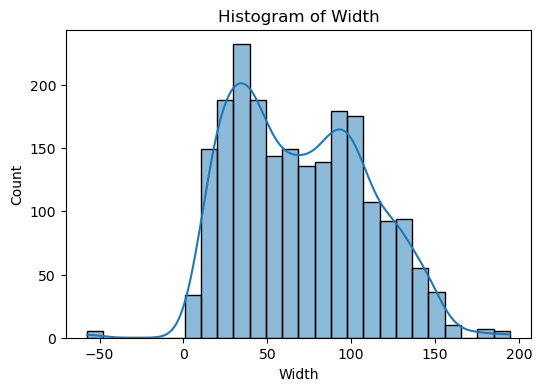

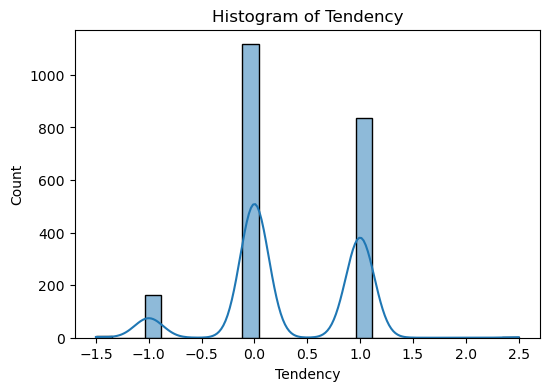

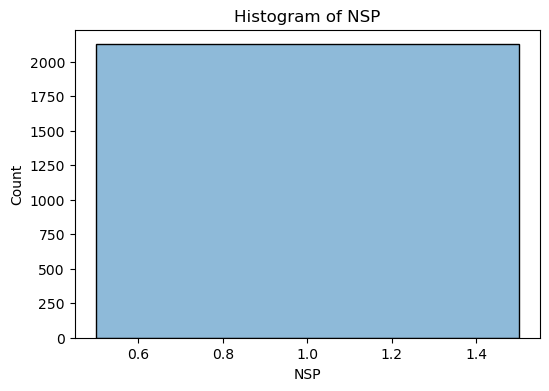

In [22]:
# Histogram
for col in df.select_dtypes(include=['int','float']).columns:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True)
    plt.title(f'Histogram of {col}')
    plt.show()

### Skewness

In [23]:
def skewness(df,column):
    mean = df[column].mean()
    median = df[column].median()
    std = df[column].std()
    a = 3*(mean-median)
    b = a/std
    return np.floor(b)
for col in df.columns:
    a = skewness(df,col)
    print(col, ":", skewness(df, col))

LB : 0.0
AC : 1.0
FM : 1.0
UC : -1.0
DL : 1.0
DS : nan
DP : nan
ASTV : -1.0
MSTV : 0.0
ALTV : 1.0
MLTV : 0.0
Width : 0.0
Tendency : 1.0
NSP : nan


### Boxplot

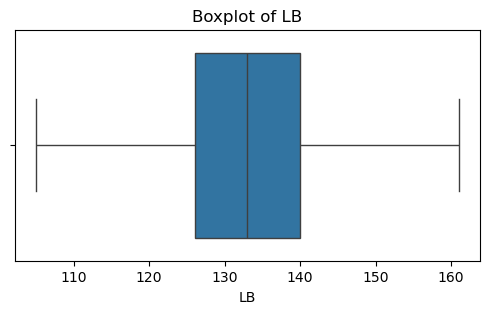

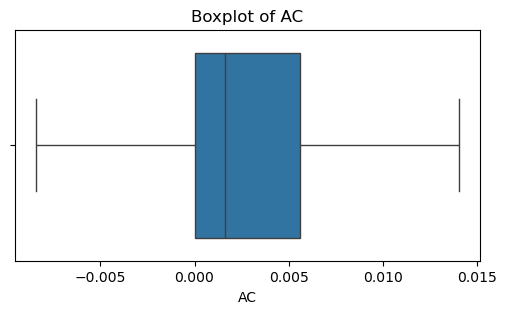

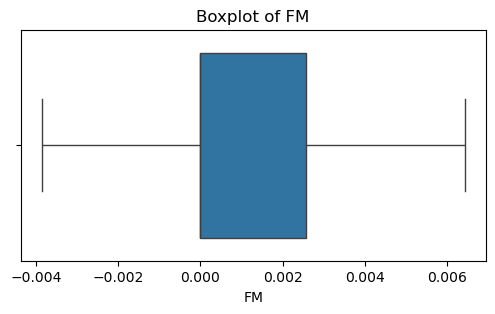

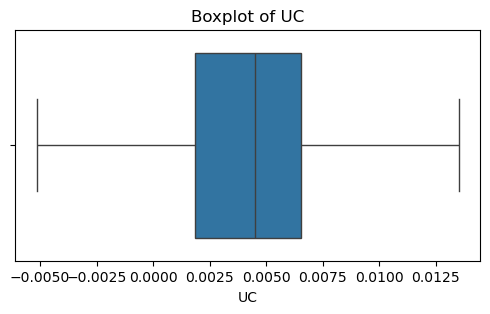

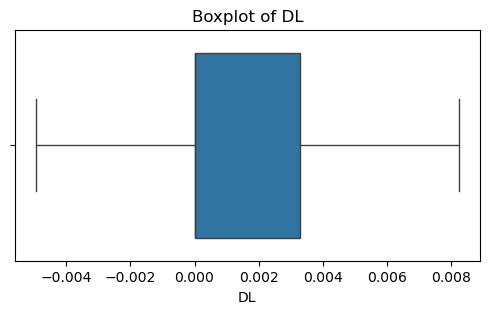

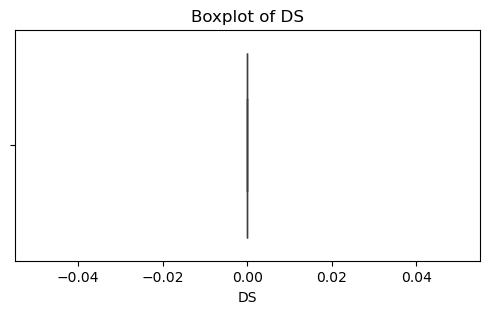

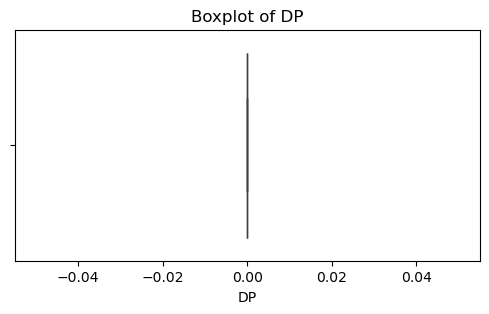

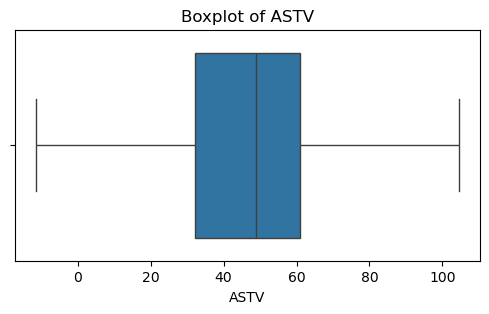

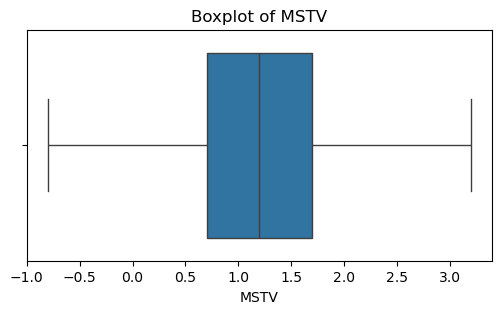

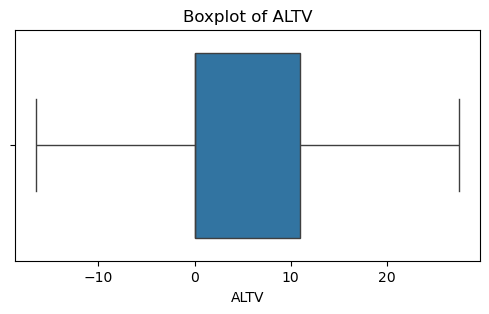

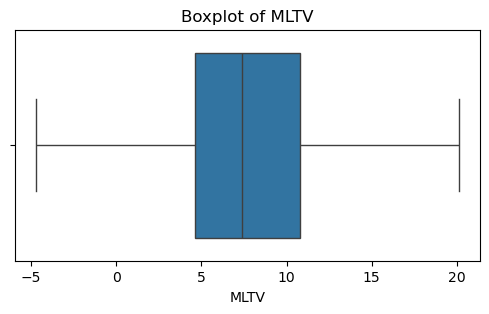

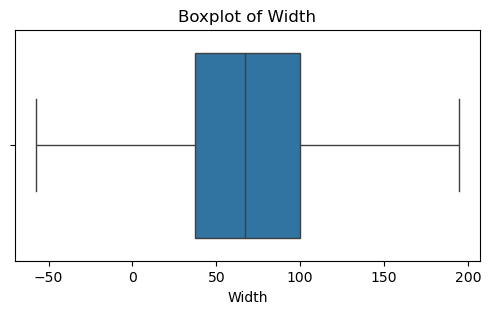

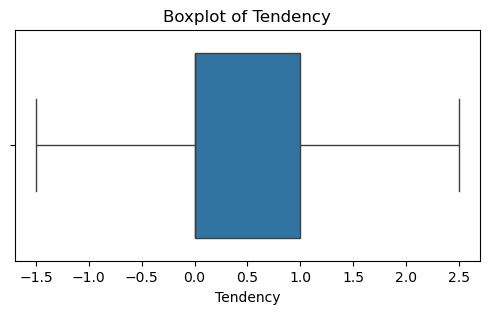

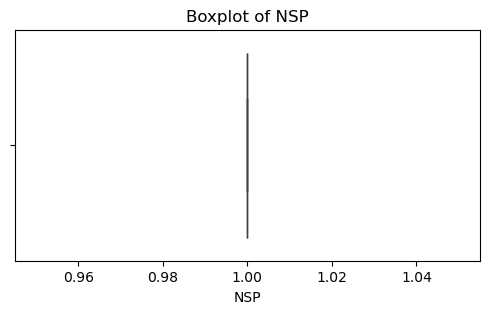

In [24]:
for col in df.columns:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()

### Bar chart 

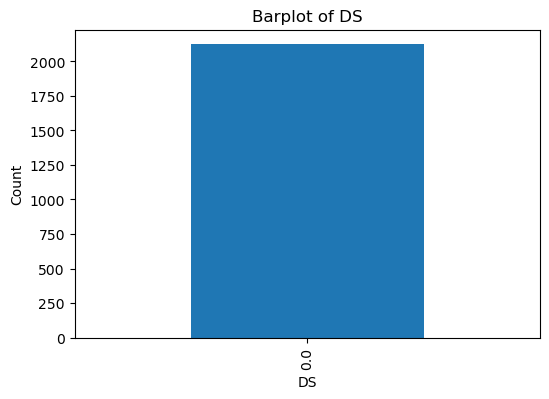

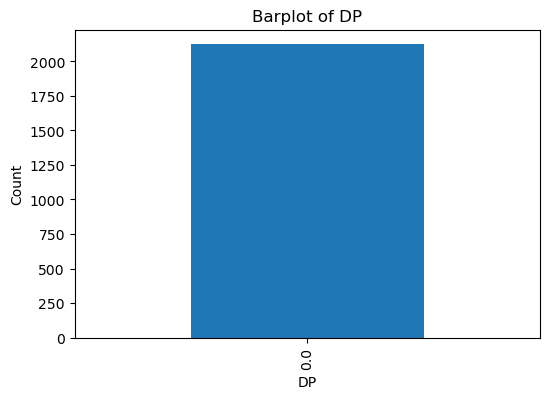

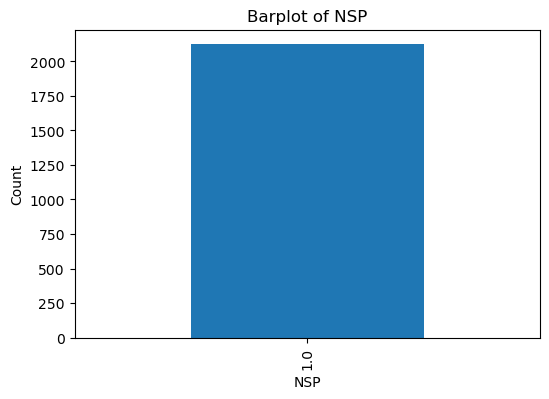

In [26]:
# Using the bar chart to show the frequency 
cat_col = ['DS', 'DP', 'NSP']

for col in cat_col:
    plt.figure(figsize=(6,4))
    df[col].value_counts().plot(kind='bar')
    plt.title(f'Barplot of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.show()

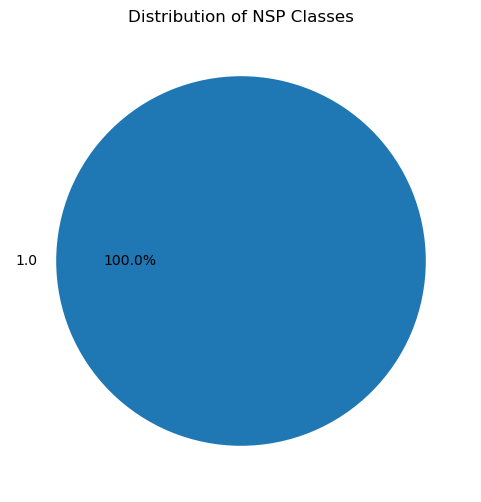

In [27]:
# Pie chart 
plt.figure(figsize=(6,6))

df['NSP'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.ylabel('')
plt.title('Distribution of NSP Classes')
plt.show()

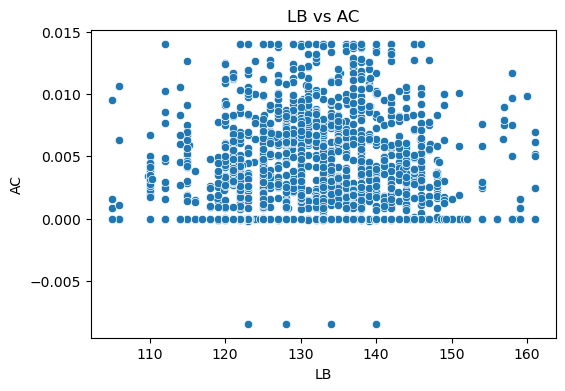

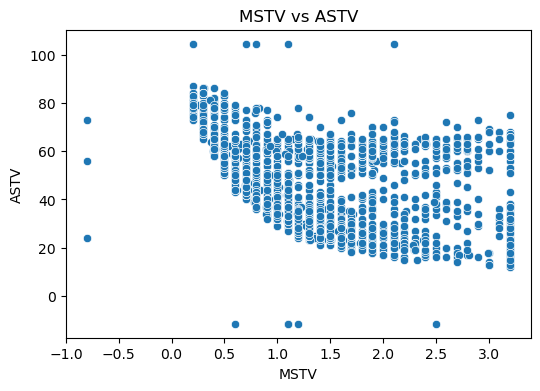

In [28]:
# Scatter plot 
plt.figure(figsize=(6,4))
sns.scatterplot(x='LB', y='AC', data=df)
plt.title('LB vs AC')
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='MSTV', y='ASTV', data=df)
plt.title('MSTV vs ASTV')
plt.show()

In [29]:
# Purpose :- 
# 1. Understand relationships between variables.
# 2. Detect trends and clusters.

### Correlation

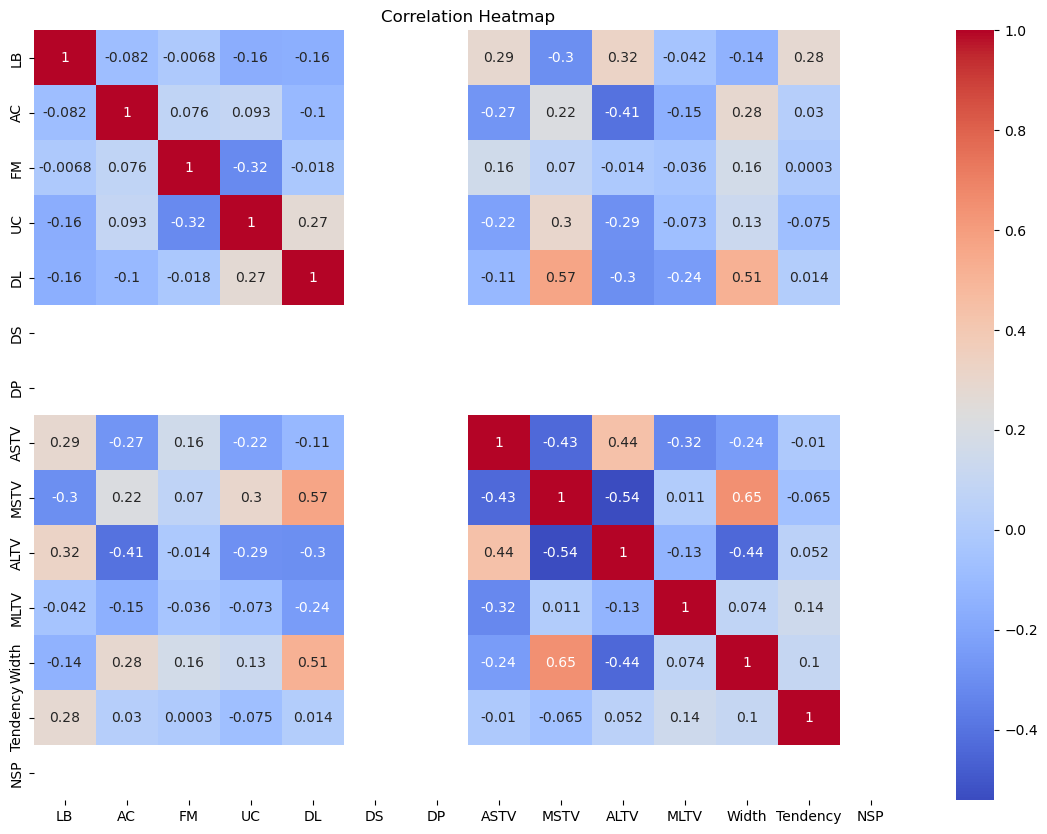

In [30]:
plt.figure(figsize=(14,10))

corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [33]:
# But if the data contains the temporal data we can use line chart as visualization to show the relation.

### Pairplot

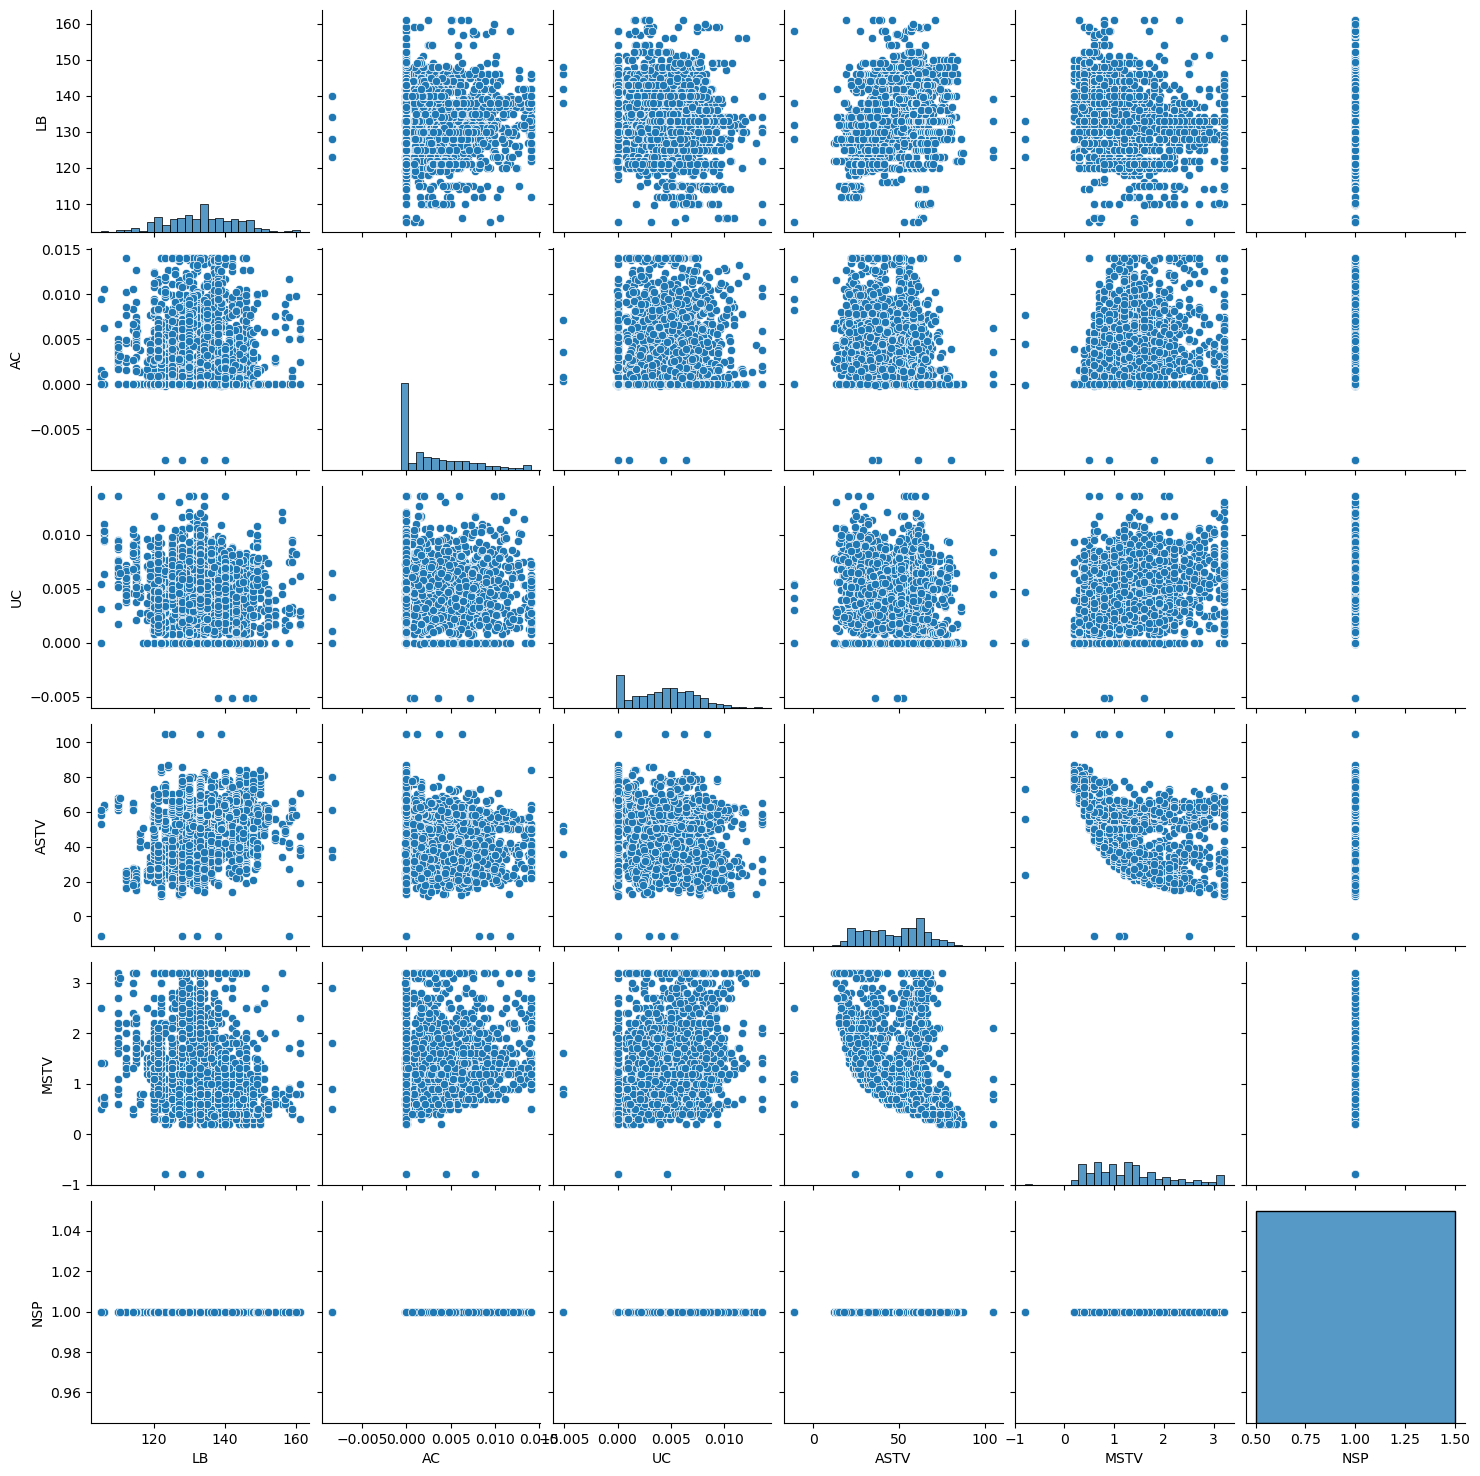

In [34]:
sns.pairplot(df[['LB', 'AC', 'UC', 'ASTV', 'MSTV', 'NSP']])
plt.show()

### Violin plots

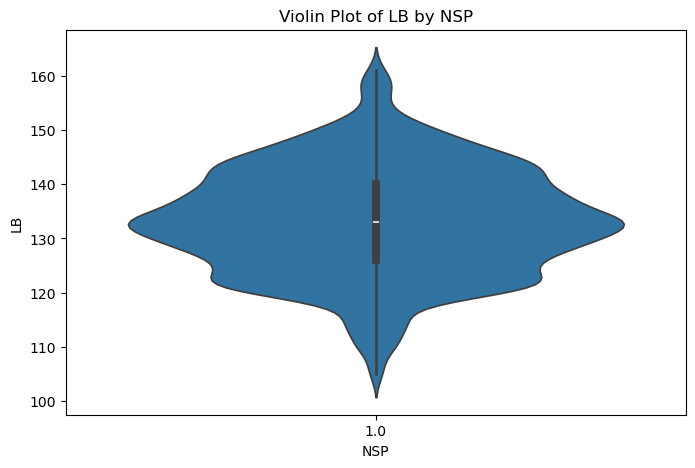

In [35]:
plt.figure(figsize=(8,5))
sns.violinplot(x='NSP', y='LB', data=df)
plt.title('Violin Plot of LB by NSP')
plt.show()

### Conclusion